#  Customer Segmentation using K-Means Clustering

# Project Overview

Customer segmentation is one of the most important applications of machine learning in business analytics. In this project, the K-Means clustering algorithm is used to divide customers into meaningful groups based on their Annual Income and Spending Score. These insights help businesses understand customer behavior, improve marketing strategies, increase customer satisfaction, and optimize business decisions through data-driven analysis.

In [5]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
plt.style.use("ggplot")
%matplotlib inline

# Project Objectives

- Analyze customer demographic and spending patterns.
- Perform Exploratory Data Analysis (EDA).
- Identify the optimal number of customer clusters using the Elbow Method.
- Apply the K-Means Clustering algorithm.
- Visualize customer segments with cluster centroids.
- Analyze each cluster's characteristics.
- Export the final segmented dataset for future business applications.

# Technologies & Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook / VS Code

In [61]:
import os
print(os.listdir("../data"))

['Customer_Segmentation_Final.csv', 'Customer_Segmentation_Result.csv', 'Mall_Customers.csv']


# Load the Dataset

The Mall Customers dataset is loaded into a Pandas DataFrame for analysis. The first five records are displayed to understand the dataset structure and verify that the data has been loaded successfully.

In [63]:
df = pd.read_csv("../data/Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Dataset Exploration

The dataset is explored by examining its structure, data types, missing values, and summary statistics to gain a better understanding of the available features.

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [17]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [18]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand customer demographics and spending patterns through various visualizations.

# Age Distribution

The histogram illustrates the distribution of customer ages. It helps identify the most common age groups in the dataset.

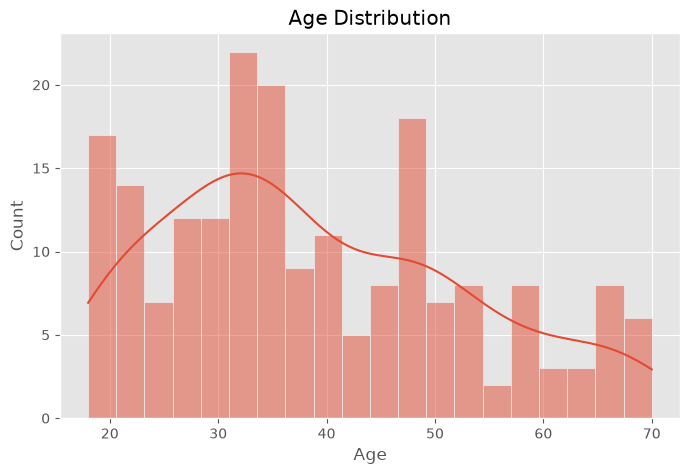

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Gender Distribution

This visualization shows the distribution of male and female customers in the dataset.

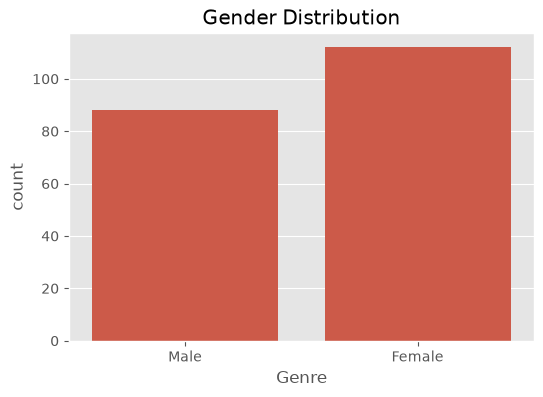

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="Genre", data=df)
plt.title("Gender Distribution")
plt.show()

# Annual Income vs Spending Score

This scatter plot illustrates the relationship between customers' annual income and spending score. It helps identify spending behavior across different income groups.

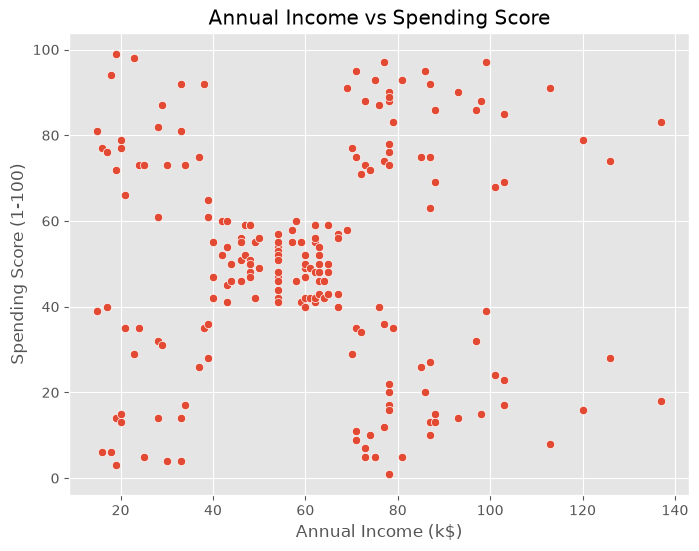

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df)
plt.title("Annual Income vs Spending Score")
plt.show()

# Correlation Heatmap

The correlation heatmap shows the relationship between numerical features. It helps understand how strongly variables are related before applying the clustering algorithm.

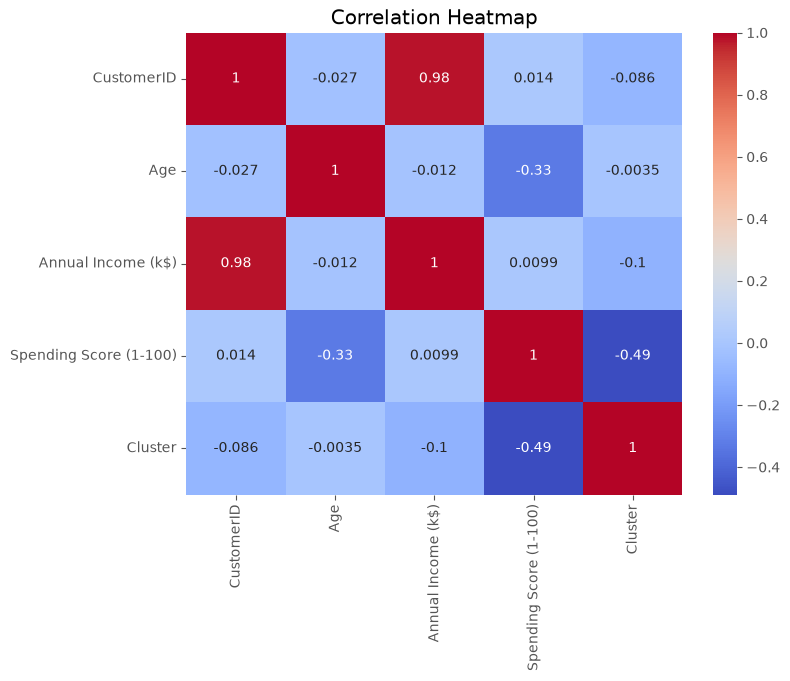

In [45]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Feature Selection

For customer segmentation, only the most relevant features are selected:
- Annual Income (k$)
- Spending Score (1–100)

These features are used as input for the K-Means clustering algorithm because they effectively represent customer purchasing behavior.

In [22]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# Elbow Method

The Elbow Method is used to determine the optimal number of clusters (K). The point where the WCSS curve starts to flatten indicates the best value of K for clustering.

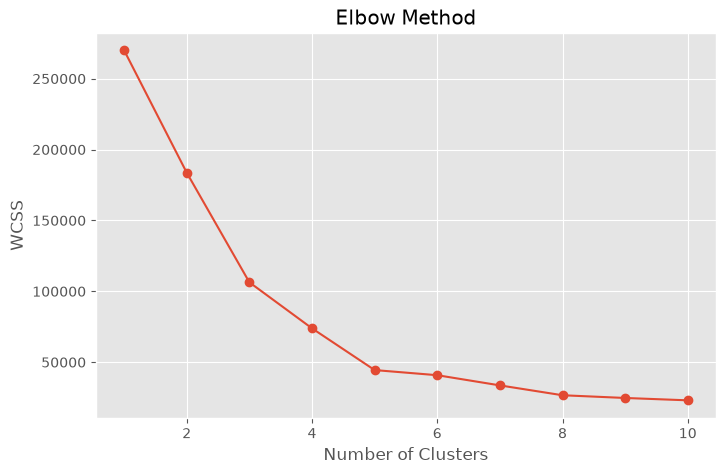

In [46]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [24]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X)
df["Cluster"] = y_kmeans
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [74]:
print(df.columns)

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


In [71]:
print(df.columns.tolist())

['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [75]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
kmeans = KMeans(n_clusters=5, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)

In [76]:
print(df["Cluster"].unique())

[4 2 0 1 3]


# Customer Segmentation Visualization

The following scatter plot visualizes the customer segments created using the K-Means clustering algorithm. Each color represents a different cluster, helping identify customer groups based on Annual Income and Spending Score.

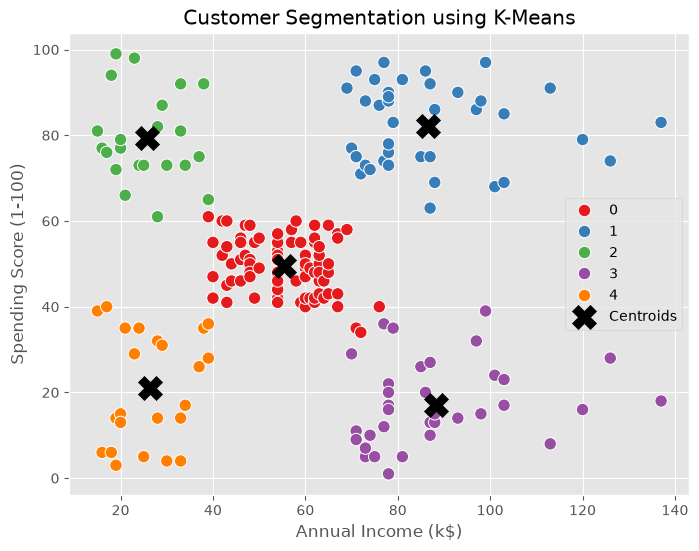

In [77]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    c="black",
    s=300,
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")
plt.legend()
plt.show()

#  Cluster Analysis

The following table presents the average values of Age, Annual Income, and Spending Score for each customer segment. This helps interpret the characteristics of every cluster.

In [48]:
cluster_means = df.groupby("Cluster").mean(numeric_only=True)
print(cluster_means)

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043


# Cluster-wise Feature Analysis

This visualization compares the average Age, Annual Income, and Spending Score for each customer cluster. It helps understand the unique characteristics of every customer segment and supports better business decision-making.

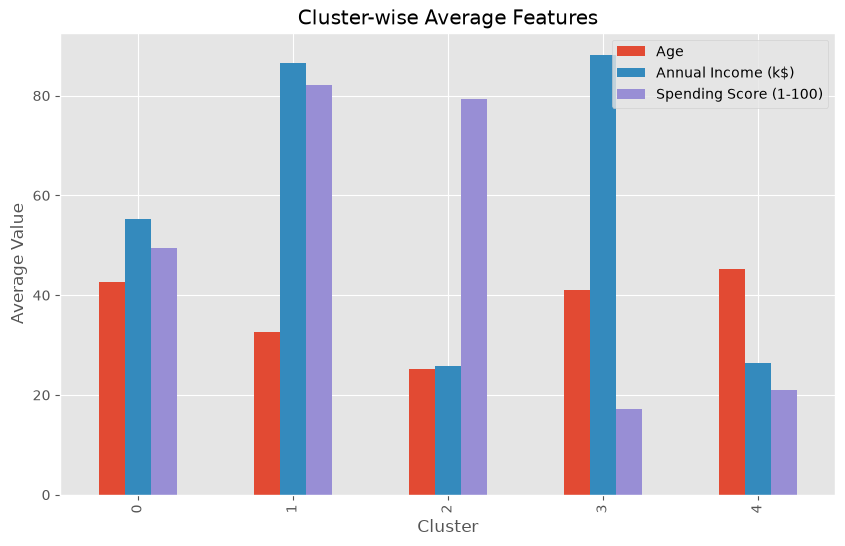

In [49]:
cluster_means[["Age","Annual Income (k$)","Spending Score (1-100)"]].plot(kind="bar", figsize=(10,6))
plt.title("Cluster-wise Average Features")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.grid(True)
plt.show()

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Clustering Evaluation

The performance of the K-Means clustering model is evaluated using different clustering metrics. These metrics measure how well the customer groups are separated and how compact the clusters are.


In [52]:
from sklearn.metrics import silhouette_score
print("Silhouette Score:", silhouette_score(X_scaled, y_kmeans))

Silhouette Score: 0.5546571631111091


In [53]:
from sklearn.metrics import davies_bouldin_score
print("Davies-Bouldin Index:", davies_bouldin_score(X_scaled, y_kmeans))

Davies-Bouldin Index: 0.5722356162263352


In [54]:
from sklearn.metrics import calinski_harabasz_score
print("Calinski-Harabasz Score:", calinski_harabasz_score(X_scaled, y_kmeans))

Calinski-Harabasz Score: 248.64932001536357


# Cluster Distribution

This section displays the number of customers assigned to each cluster after applying the K-Means clustering algorithm. It helps analyze how customers are distributed across different segments and whether the clusters are balanced for further business analysis.

In [55]:
print(df["Cluster"].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [56]:
print((df["Cluster"].value_counts(normalize=True)*100).round(2))

Cluster
0    40.5
1    19.5
3    17.5
4    11.5
2    11.0
Name: proportion, dtype: float64


# Cluster Statistics

The table below summarizes the mean, minimum, and maximum values of Age, Annual Income, and Spending Score for each customer cluster. This analysis helps interpret the characteristics and behavior of every customer segment.

In [57]:
print(df.groupby("Cluster")[["Age","Annual Income (k$)","Spending Score (1-100)"]].agg(["mean","min","max"]))

               Age         Annual Income (k$)          Spending Score (1-100)  \
              mean min max               mean min  max                   mean   
Cluster                                                                         
0        42.716049  18  70          55.296296  39   76              49.518519   
1        32.692308  27  40          86.538462  69  137              82.128205   
2        25.272727  18  35          25.727273  15   39              79.363636   
3        41.114286  19  59          88.200000  70  137              17.114286   
4        45.217391  19  67          26.304348  15   39              20.913043   

                 
        min max  
Cluster          
0        34  61  
1        63  97  
2        61  99  
3         1  39  
4         3  40  



# Export Final Dataset

The final dataset containing cluster labels is exported as a CSV file for future business analysis and decision-making.

In [58]:
df.to_csv("../data/Customer_Segmentation_Final.csv", index=False)
print("Final Dataset Saved Successfully!")

Final Dataset Saved Successfully!


# Conclusion

This project successfully segments customers into different groups using the K-Means Clustering algorithm. By analyzing customer demographics, annual income, and spending behavior, meaningful customer segments were identified. These insights can help businesses improve marketing strategies, personalize customer experiences, and make data-driven decisions.